# Title: Heart Disease Prediction 
`Author:` [Md Mamun Rasid Prodhan](https://www.linkedin.com/in/mamun-rasid-prodhan/)\
`Dataset:` [UCI Heart Disease Data](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

## Meta Data (About Dataset)
## Context
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
### Column Descriptions:
1. `id` (Unique id for each patient)
2. `age` (Age of the patient in years)
3. `origin` (place of study)
4. `sex` (Male/Female)
5. `cp` chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
6. `trestbps` resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
7. `chol` (serum cholesterol in mg/dl)
8. `fbs` (if fasting blood sugar > 120 mg/dl)
9. `restecg` (resting electrocardiographic results)\
    -- Values: [normal, stt abnormality, lv hypertrophy]
10. `thalach:` maximum heart rate achieved
11. `exang:` exercise-induced angina (True/ False)
12. `oldpeak:` ST depression induced by exercise relative to rest
13. `slope:` the slope of the peak exercise ST segment
14. `ca:` number of major vessels (0-3) colored by fluoroscopy
15. `thal:` [normal; fixed defect; reversible defect]
16. `num:` the predicted attribute
### Acknowledgements
#### Creators:
1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
#### Relevant Papers:
- Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
- David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database." 
- Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61.
#### Citation Request:
The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution. They would be:

1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

## Aims and Objective:
fill this after EDA

### Import Libraries
Let's start the project by importing all the libries that will need.

In [1]:
# import libraries

# 1. to handle the data 
import pandas as pd
import numpy as np

# 2. to visualize the data 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

# 3. To preprocess the data 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer 
# import iterative imputer 
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer 

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error

# ignore warnings   
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [2]:
# load the dataset from a csv file 
df = pd.read_csv('heart_disease_uci.csv')

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)
### Explore each column

In [3]:
# exploring the datatype of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.shape

(920, 16)

In [4]:
#id column
df['id'].min(), df['id'].max()

(1, 920)

In [5]:
# age column
df['age'].min(), df['age'].max()

(28, 77)

Text(0.5, 1.0, 'Age distribution')

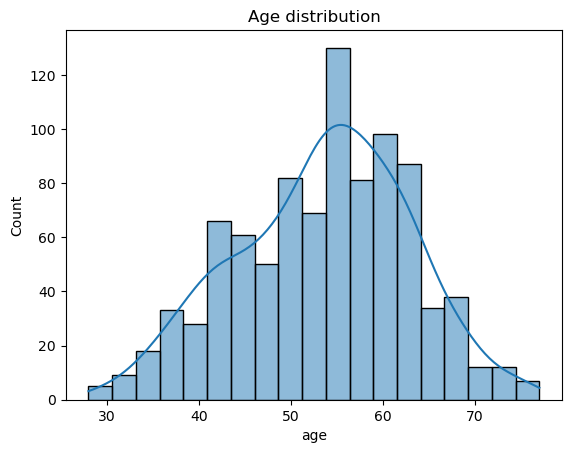

In [3]:
# draw a histogram to see the distribution of age column
sns.histplot(df['age'], kde = True)
plt.title('Age distribution')

Mean of age:  53.51086956521739
Median of age:  54.0
Mode of age:  54


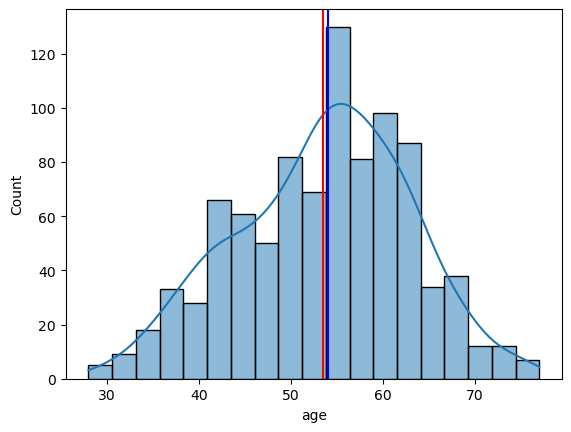

In [4]:
# plot mean median and mod of age column using sns
sns.histplot(df['age'], kde = True)
plt.axvline(df['age'].mean(), color = 'red')
plt.axvline(df['age'].median(), color = 'green')
plt.axvline(df['age'].mode()[0], color = 'blue')

print('Mean of age: ', df['age'].mean())
print('Median of age: ', df['age'].median())
print('Mode of age: ', df['age'].mode()[0])

In [8]:
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [5]:
# calculate the percent of male and female data in the dataset
male_count = 726
female_count = 194
total_count = male_count + female_count

# calculate percentages
male_percentages = (male_count/total_count) * 100
female_percentages = (female_count/total_count) * 100

print(f'Male percentage in the data: {male_percentages: .2f}%')
print(f'Female percentage in the data: {female_percentages: .2f}%')

Male percentage in the data:  78.91%
Female percentage in the data:  21.09%


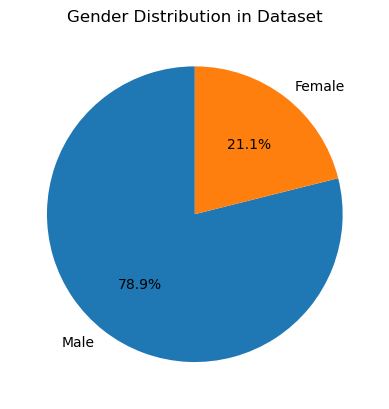

In [6]:
labels = ['Male', 'Female']
size = [male_count, female_count]

plt.pie(
    size,
    labels = labels,
    autopct = '%1.1f%%',
    startangle = 90
)
plt.title('Gender Distribution in Dataset')
plt.show()

In [11]:
# find the value count of age column grouping by sex column
df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [12]:
# let's Deal with dataset column
# find the unique values in dataset column
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [13]:
# find unique values count in dataset column
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

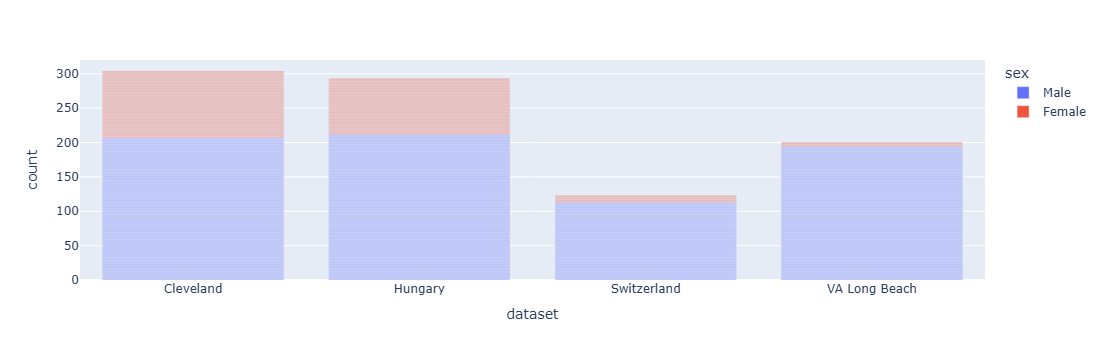

In [7]:
# plot the countplot of dataset column
# sns.countplot(data =df, x = 'dataset', hue = 'sex')

# better plot with plotly
fig = px.bar(df, x = 'dataset', color = 'sex')
fig.show()

In [8]:
df.groupby('sex')['dataset'].value_counts()

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64

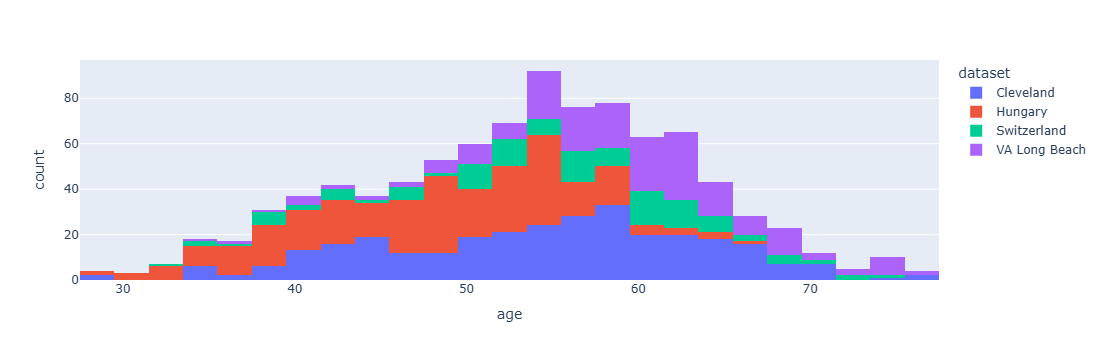

Mean of the dataset: dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64


In [9]:
# make a plot of age column using plotly and coloring this by dataset column
fig = px.histogram(data_frame = df, x = 'age', color = 'dataset')
fig.show()

# print the mean median and mode of age column grouped by dataset column
print(f'Mean of the dataset: {df.groupby('dataset')['age'].mean()}')

### Let's explore CP(Chest Pain) column

In [17]:
# value count of cp column
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

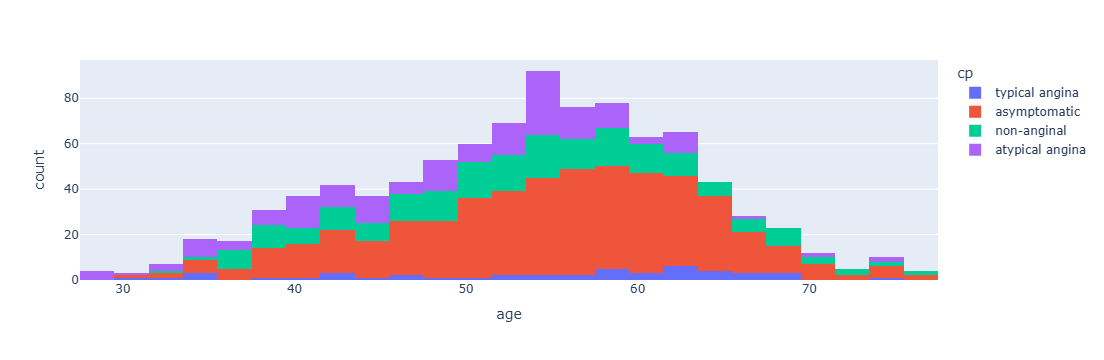

In [10]:
# draw the plot of age column group by cp column using plotly
fig = px.histogram(data_frame = df, x = 'age', color = 'cp')
fig.show()

<Axes: xlabel='sex', ylabel='count'>

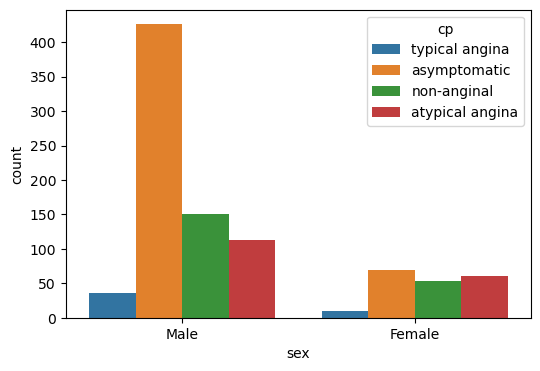

In [11]:
# count plot of cp column by sex column 
# sns.fig_size = (1,1)
plt.figure(figsize=(6, 4))
sns.countplot(df,x = 'sex', hue = 'cp')


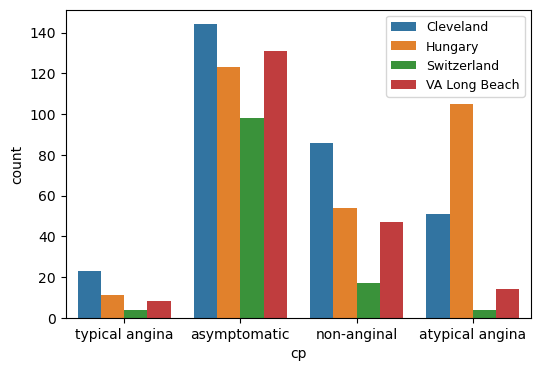

In [12]:
# count plot of cp column by dataset column 
plt.figure(figsize=(6, 4))
sns.countplot(df,x = 'cp', hue = 'dataset')
plt.legend(fontsize=9)

In [21]:
df.groupby('cp')['age'].mean()

cp
asymptomatic       54.959677
atypical angina    49.241379
non-anginal        53.333333
typical angina     54.826087
Name: age, dtype: float64

### Let's explore the trestbps (resting blood pressure) column:

The normal blood pressure is 120/80 mm Hg.

In [22]:
# describe the trestbps column 
df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

<Axes: xlabel='trestbps', ylabel='Count'>

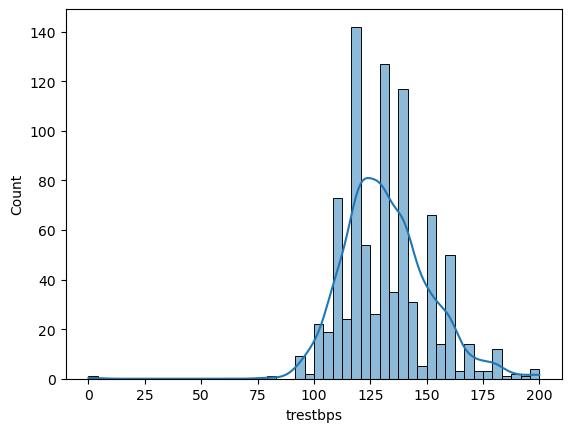

In [13]:
# create a hist plot of trestbps column
sns.histplot(df['trestbps'], kde = True)

In [12]:
# The percentage of missing values in trestbps column 
print(f'Percentage of missing values in trestbps column: {df['trestbps'].isnull().sum() / len(df) *100:.2f}%')

Percentage of missing values in trestbps column: 6.41%


In [14]:
# impute the missing values of trestbps column using iterative imputer 
imputer = IterativeImputer(max_iter = 10, random_state= 42)

# fit the imputer to the trestbps column 
imputer.fit(df[['trestbps']])
df['trestbps'] = imputer.transform(df[['trestbps']])


In [15]:
df['trestbps'].isnull().sum()

0

# Impute Numeric Column Missing Values

In [16]:
# impute the missing values using iterative imputer for ca, oldpeak, thalch , chol columns 
imputer_2 = IterativeImputer( max_iter = 10, random_state= 42)
num_col = ['ca', 'oldpeak','thalch', 'chol']

for i in num_col:
    df[i] = imputer_2.fit_transform(df[[i]])

In [17]:
df.isnull().sum().sort_values(ascending = False)

thal        486
slope       309
fbs          90
exang        55
restecg       2
id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
thalch        0
oldpeak       0
ca            0
num           0
dtype: int64

# Let's impute the missing values in by using ML models 

In [18]:
print(f'The missing values in thal column are: {df['thal'].isnull().sum()/ len(df) * 100:.2f}%')

The missing values in thal column are: 52.83%


In [19]:
df['thal'].value_counts()

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

### Write down the function to impute the missing values in by using ML models and reuse that function on other columns as well.

In [20]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
missing_data_cols

['fbs', 'restecg', 'exang', 'slope', 'thal']

In [21]:
# find only categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
# find only numerical columns
num_cols = df.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical Columns: {cat_cols}')
print(f'Numerical Columns: {num_cols}')

Categorical Columns: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Columns: ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


impute_categorical_missing_Values(df['thal'])

In [22]:
categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
numeric_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [23]:
# define the function to impute the missing values in thal column

def impute_categorical_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_classifier = RandomForestClassifier()

    rf_classifier.fit(X_train, y_train)

    y_pred = rf_classifier.predict(X_test)

    acc_score = accuracy_score(y_test, y_pred)

    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
        else:
            pass
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf_regressor = RandomForestRegressor()

    rf_regressor.fit(X_train, y_train)

    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
    print("RMSE =", mean_squared_error(y_test, y_pred, squared=False), "\n")
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
        else:
            pass
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)
    else:
        pass

    df_combined = pd.concat([df_not_null, df_null])
    
    return df_combined[passed_col]

In [24]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

thal       486
slope      309
fbs         90
exang       55
restecg      2
dtype: int64

In [25]:
# remove warning
import warnings
warnings.filterwarnings('ignore')

# impute missing values using our functions
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)
    else:
        pass

Missing Values fbs : 9.78%
The feature 'fbs' has been imputed with 78.92 accuracy

Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 67.93 accuracy

Missing Values exang : 5.98%
The feature 'exang' has been imputed with 79.77 accuracy

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 65.04 accuracy

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 73.56 accuracy



In [26]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

# Dealing With Outliers 

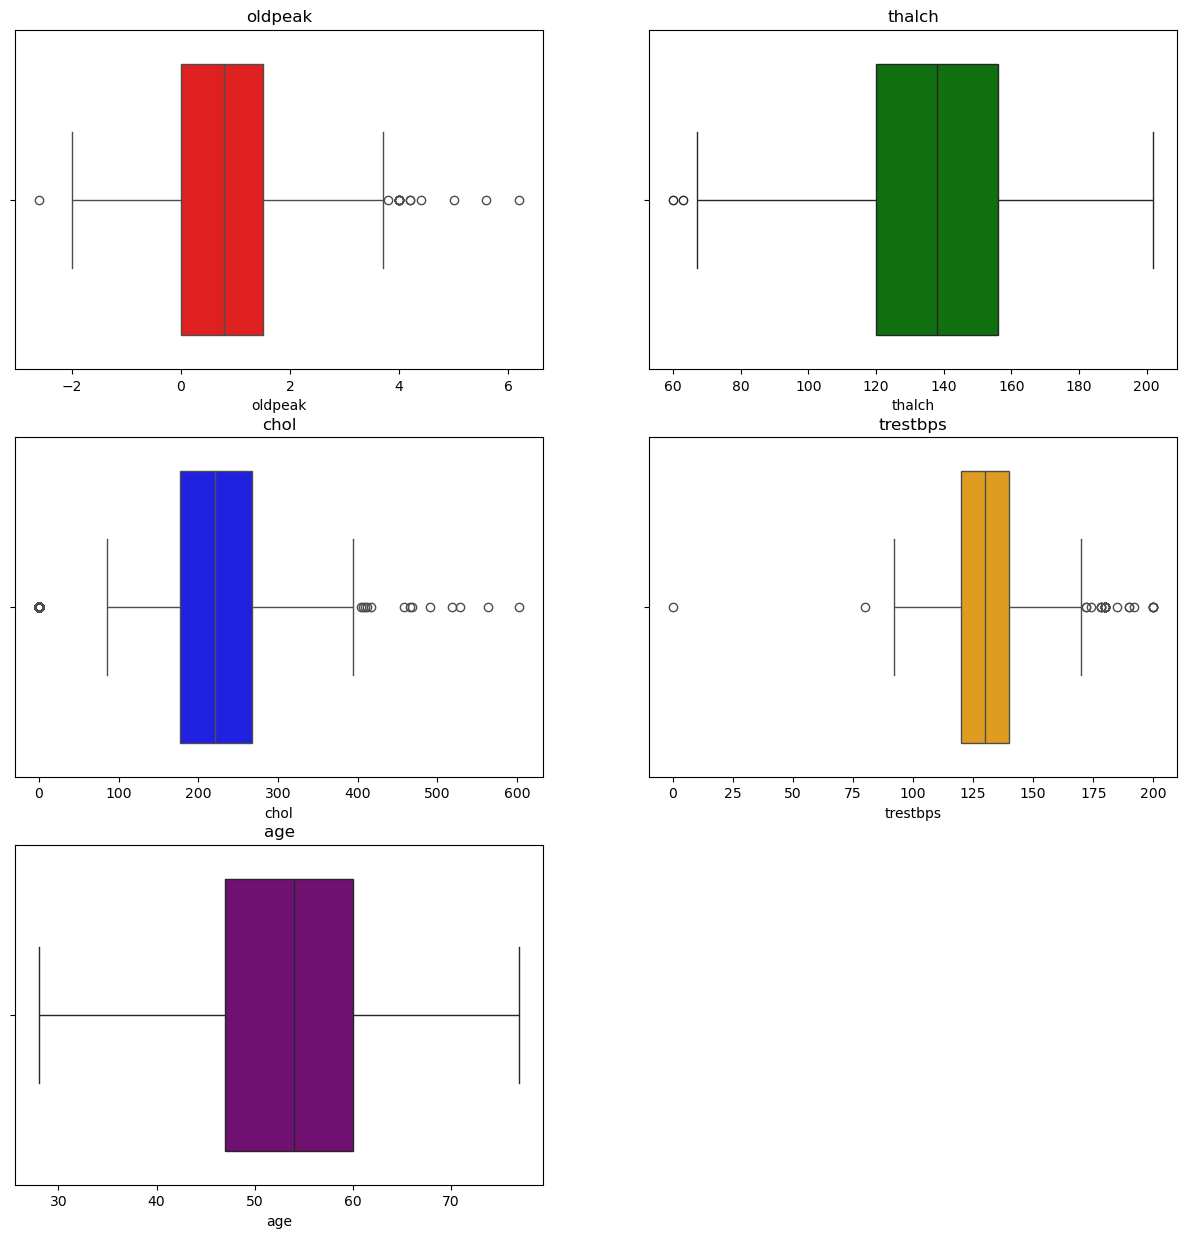

In [28]:
# create box plots for all numeric columns using for loop and subplot 
plt.figure(figsize = (15,15))
colors = ['red','green', 'blue','orange', 'purple']
for i, col in enumerate(numeric_cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(x = df[col], color = colors[i])
    plt.title(col)
plt.show()

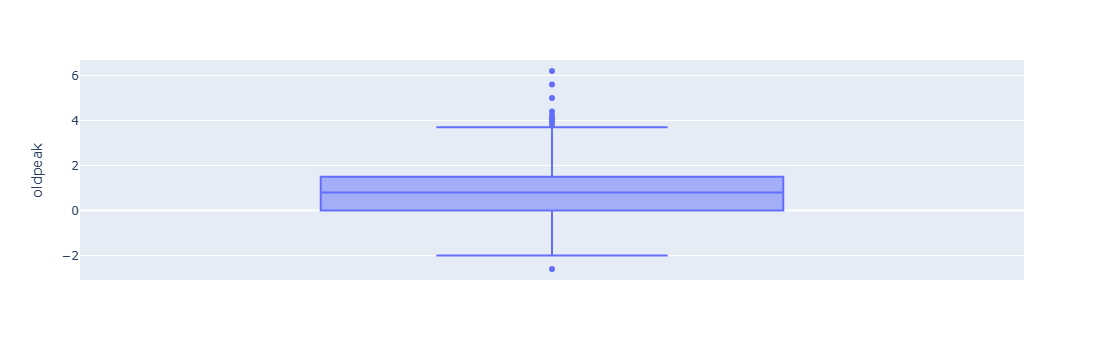

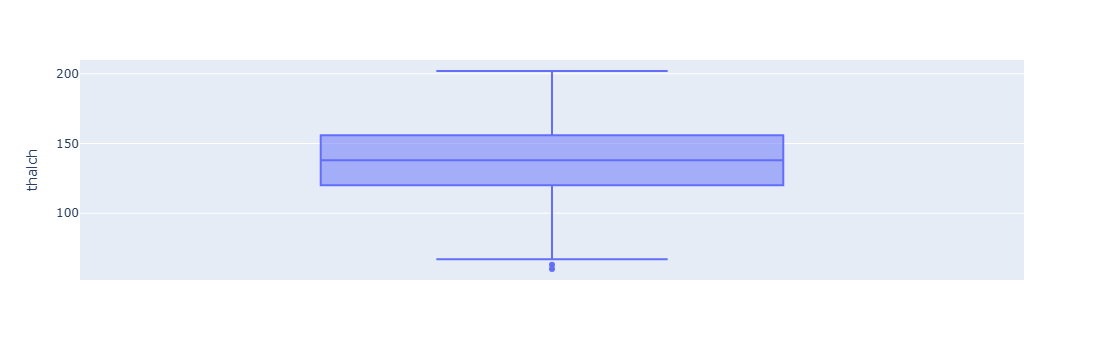

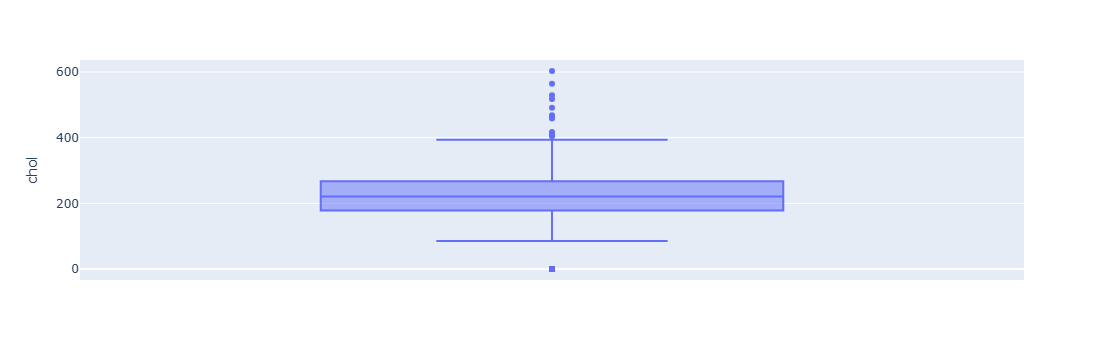

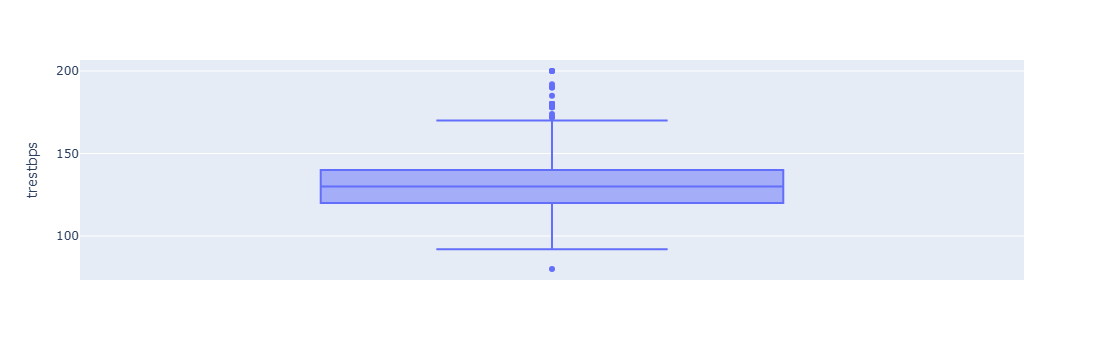

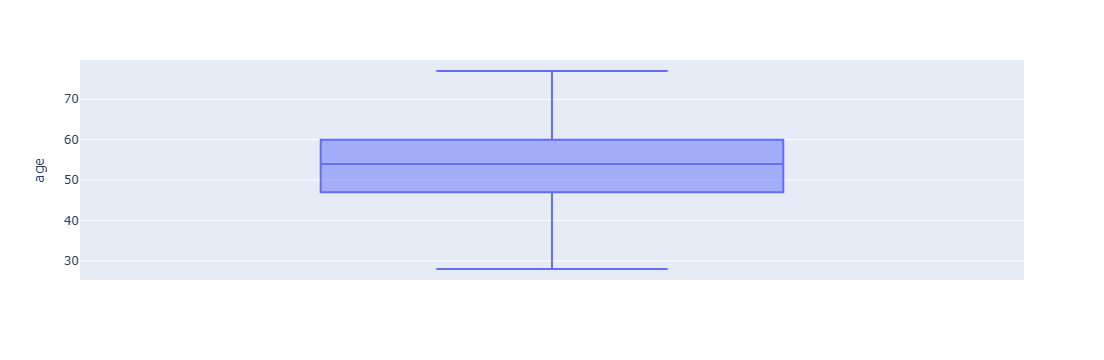

In [45]:
# make box plot of all the numeric columns using for loop and plotly 

for i in numeric_cols:
    fig = px.box(data_frame = df, y = i)
    fig.show()

In [43]:
# remove the row in which trestbps is 0
df = df[df['trestbps'] !=0]

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        919 non-null    int64  
 1   age       919 non-null    int64  
 2   sex       919 non-null    object 
 3   dataset   919 non-null    object 
 4   cp        919 non-null    object 
 5   trestbps  919 non-null    float64
 6   chol      919 non-null    float64
 7   fbs       919 non-null    object 
 8   restecg   919 non-null    object 
 9   thalch    919 non-null    float64
 10  exang     919 non-null    object 
 11  oldpeak   919 non-null    float64
 12  slope     919 non-null    object 
 13  ca        919 non-null    float64
 14  thal      919 non-null    object 
 15  num       919 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 122.1+ KB


# <span style="color:yellow; font-size:50px">Machine Learning </span>

In [50]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    106
4     28
Name: count, dtype: int64

In [60]:
# split the data into x and y 
X = df.drop('num', axis = 1)
y = df['num']

# dictionary to store encoder for each column
encoder = {}
# encode categorical columns separately
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

        encoder[col] = le

# split the data for train and test
X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size = 0.2, random_state= 42)

Enlist all the models that will use to predict the heart disease. This models models should be classifiers for multi-class classification.
1. logistic regression
2. KNN
3. NB
4. SVM
5. Decision Tree
6. Random Forest
7. XGBoost
8. GradientBoosting
9. AdaBoost
10. lightGBM

In [58]:
# import all the models 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# from lightgbm import LGBMClassifier

# impot pipeline
from sklearn.pipeline import Pipeline

# import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [61]:
# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
    ('Support Vector Machine', SVC(random_state=42)),
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Ada Boost', AdaBoostClassifier(random_state=42)),
    ('XG Boost', XGBClassifier(random_state=42)),
    ('Naive Bayes', GaussianNB())
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        # ('imputer', SimpleImputer(strategy='most_frequent')),
        # ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('model', model)
    ])
    
    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    
    # Calculate mean accuracy
    mean_accuracy = scores.mean()
    
    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)
    
    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    
    # Print the performance metrics
    print("Model:", name)
    print("Cross-validation Accuracy:", mean_accuracy)
    print("Test Accuracy:", accuracy)
    print()
    
    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the best model
print("Best Model:", best_model)

Model: Random Forest
Cross-validation Accuracy: 0.6340136054421769
Test Accuracy: 0.6195652173913043

Model: Gradient Boosting
Cross-validation Accuracy: 0.616326530612245
Test Accuracy: 0.6467391304347826

Model: Support Vector Machine
Cross-validation Accuracy: 0.582312925170068
Test Accuracy: 0.5815217391304348

Model: Logistic Regression
Cross-validation Accuracy: 0.5210884353741496
Test Accuracy: 0.4891304347826087

Model: K-Nearest Neighbors
Cross-validation Accuracy: 0.580952380952381
Test Accuracy: 0.592391304347826

Model: Decision Tree
Cross-validation Accuracy: 0.5755102040816327
Test Accuracy: 0.625

Model: Ada Boost
Cross-validation Accuracy: 0.5768707482993196
Test Accuracy: 0.5760869565217391

Model: XG Boost
Cross-validation Accuracy: 0.616326530612245
Test Accuracy: 0.6195652173913043

Model: Naive Bayes
Cross-validation Accuracy: 0.5714285714285714
Test Accuracy: 0.5217391304347826

Best Model: Pipeline(steps=[('model', GradientBoostingClassifier(random_state=42))])


The Target Column is `num` Which is the predicted attribute. We will use this column to predict heart disease. The unique values in this column are: [0,1,2,3,4], which state that there are 5 types of heart disease.
 - `0 = no heart disease`
 - `1 = mild heart disease`
 - `2 = moderate heart disease`
 - `3 = severe heart disease`
 - `4 = critical heart disease`

### Outputs:
1. The minimum age to have a heart disease starts from 28 years old.
2. Most of the people get heart disease at the age of 53-54 years
3. Male percentage in the data:  78.91%
4. Female percentage in the data:  21.09%
5. we have highest number of people from Cleveland (3o4) and lowest from Switzerland (123).
   1. The highest number of females in this dataset are from Cleveland(97) and lowest number are from VA-Long-each(6)
   2. The highest number of Male in this dataset are from Hungary (212) and lowest number are from Switzerland (113)
6. there are 4 types in cp column:
   1. `Asymptomatic`: Person does not feel chest pain.
   2. `Non-anginal Pain`: Chest pain not related to the heart.
   3. `Atypical Angina`: Chest discomfort related to the heart but not classic symptoms.
   4. `Typical Angina`: Classic heart-related chest pain. \
      
    From this `Atypical Angina` and `Typical Angina` are two type which define chest pain
7. typical chest pain found in people at average age 54
8. Impute the missing values using KNN imputer for the numerical column
9. Impute missing values for the categorical columns using Iterative imputer with the help of Randome Forest
10. Dealing with the outliers:
    1. first check the outliesr using plotly graph
    2. less important rows are removed